## Configuration
Set all input/output paths below before running any other cells.

### Summary

Pre-processes ice-front proximal OMG CTD/AXCTD profiles and runs a buoyant plume model ensemble.

**Data sources:**
- OMG regular CTD casts (`OMG_L2_CTD_1`) and AXCTD deployments (`OMG_AXCTD`)
- Profiles filtered to fjord-proximal casts using the Mas e Braga et al. 2025 classification CSV

**Processing steps:**
1. Filter files by fjord date classifications
2. Interpolate all profiles to a common depth grid; pad missing top/bottom
3. Smooth and QC-filter (gross range + spike checks)
4. Run buoyant plume model ensemble via Latin Hypercube Sampling:
   - **Q₀**: subglacial discharge (0.005–5 m³/s)
   - **α**: entrainment coefficient (0.05–0.15; Slater et al. 2022, Kimura et al. 2014)
   - **z_max**: max depth factor (0.6–1.4 × fjord depth)

## Imports

In [1]:
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
import warnings
from tqdm.notebook import tqdm
from pyDOE import lhs
from dask.distributed import Client, LocalCluster
from dask import delayed, compute
import geopandas as gpd

In [2]:
import yaml
from pathlib import Path

with open(Path('../../config.yaml')) as _f:
    cfg = yaml.safe_load(_f)

# REPO ROOT IS TWO LEVELS UP FROM THIS FILE NEED TO ADJUST PATHS ACCORDINGLY
repo_root = Path('../../')

# OMG CTD directory (set in config.yaml under paths.omg_ctd_dir) CONFIG PRESUMES script is in root, so need to adjust path for this script 
combined_ctd_dir = repo_root / cfg['paths']['omg_ctd_dir']

# Mas e Braga et al. 2025 fjord-classification CSV
axctd_date_filter_csv = repo_root / "data" / "fjords_gl_sill_depths_reduced.csv"

# Pre-processed OMG CTD profiles (written by process_ctd_profiles, read back by later cells)
OUTPUT_NC_PATH = repo_root / "data" / "ctd_plume_simulations" / "omg_ctd_profiles.nc"

# Buoyant plume ensemble results
plume_output_path = repo_root / "data" / "ctd_plume_simulations" / "omg_plume_ensemble.nc"

# print paths to check they are correct
print(f"Combined CTD directory: {combined_ctd_dir}")
print(f"AxCTD date filter CSV: {axctd_date_filter_csv}")
print(f"Output NC path: {OUTPUT_NC_PATH}")
print(f"Plume output path: {plume_output_path}")

Combined CTD directory: ..\..\data\external\OMG_CTD_AXCTD_data
AxCTD date filter CSV: ..\..\data\fjords_gl_sill_depths_reduced.csv
Output NC path: ..\..\data\ctd_plume_simulations\omg_ctd_profiles.nc
Plume output path: ..\..\data\ctd_plume_simulations\omg_plume_ensemble.nc


## Helper Functions

In [3]:
def get_filtered_file_lists(axctd_date_csv_path, combined_ctd_dir):
    """Finds all OMG CTD/AXCTD NetCDF files filtered to fjord-classified dates (Mas e Braga et al. 2025)."""
    all_files = glob.glob(os.path.join(combined_ctd_dir, 'OMG_Ocean*.nc'))
    print(f'Total files in directory: {len(all_files)}')

    fjords_gl_sill_depths = pd.read_csv(axctd_date_csv_path, dtype=str, encoding='latin-1')
    fjord_columns = [col for col in fjords_gl_sill_depths.columns if col.startswith('fjord')]
    fjord_values = {col: fjords_gl_sill_depths[col].dropna().tolist() for col in fjord_columns}

    dates_OMG = []
    for col, values in fjord_values.items():
        dates_OMG.extend([int(float(v)) for v in values if pd.notna(v)])
    dates_OMG = sorted(set(dates_OMG))

    filtered = [f for f in all_files if any(str(date) in f for date in dates_OMG)]
    print(f'Files after Mas e Braga date filter: {len(filtered)}')
    return filtered


def open_and_extract(file):
    """Opens a single OMG NetCDF file and eagerly loads profile data."""
    try:
        with xr.open_dataset(file) as ds:
            return {
                'temperature': ds['temperature'].load().squeeze(),
                'salinity': ds['salinity'].load().squeeze(),
                'depth': ds['depth'].load().squeeze(),
                'density': ds['density'].load().squeeze(),
                'date': ds['time'].values[0],
                'lat': ds['lat'].values[0],
                'lon': ds['lon'].values[0],
                'file': file
            }
    except RuntimeError as e:
        warnings.warn(f"Failed to open file: {file}. Error: {e}. Skipping.")
        return None
    except Exception as e:
        warnings.warn(f"Error processing file {file}: {e}. Skipping.")
        return None


def process_and_interp_profile(ds, new_depth_coord):
    """Pads a profile to 0 m (top) and grid max (bottom), then interpolates onto the common depth grid."""
    temp_profile = ds['temperature']
    sal_profile = ds['salinity']
    depth_profile = ds['depth']
    dens_profile = ds['density']

    # Clip to non-negative depths
    if depth_profile.min().values < 0:
        mask = depth_profile >= 0
        temp_profile = temp_profile.where(mask, drop=True)
        sal_profile = sal_profile.where(mask, drop=True)
        depth_profile = depth_profile.where(mask, drop=True)
        dens_profile = dens_profile.where(mask, drop=True)

    # Top padding: extend shallowest value up to 0 m
    if depth_profile.min().values > 0:
        top_n = int(depth_profile.min().values)
        if top_n > 0:
            extended_temp_profile = np.concatenate([np.full(top_n, temp_profile[0].values.item()), temp_profile.values.flatten()])
            extended_sal_profile = np.concatenate([np.full(top_n, sal_profile[0].values.item()), sal_profile.values.flatten()])
            extended_depth_profile = np.concatenate([np.arange(top_n), depth_profile.values.flatten()])
            extended_dens_profile = np.concatenate([np.full(top_n, dens_profile[0].values.item()), dens_profile.values.flatten()])
        else:
            extended_temp_profile = temp_profile.values.flatten()
            extended_sal_profile = sal_profile.values.flatten()
            extended_depth_profile = depth_profile.values.flatten()
            extended_dens_profile = dens_profile.values.flatten()
    else:
        extended_temp_profile = temp_profile.values.flatten()
        extended_sal_profile = sal_profile.values.flatten()
        extended_depth_profile = depth_profile.values.flatten()
        extended_dens_profile = dens_profile.values.flatten()

    # Bottom padding: extend deepest value to grid max with NaNs
    padding_length = int(new_depth_coord[-1] - depth_profile.max().values)
    if padding_length > 0:
        bottom_depth_padding = np.linspace(depth_profile.max().values, new_depth_coord[-1], num=padding_length + 1)[1:]
        extended_temp_profile = np.concatenate([extended_temp_profile, np.full(padding_length, np.nan)])
        extended_sal_profile = np.concatenate([extended_sal_profile, np.full(padding_length, np.nan)])
        extended_depth_profile = np.concatenate([extended_depth_profile, bottom_depth_padding])
        extended_dens_profile = np.concatenate([extended_dens_profile, np.full(padding_length, np.nan)])

    if not (len(extended_depth_profile) == len(extended_temp_profile) == len(extended_sal_profile) == len(extended_dens_profile)):
        warnings.warn(f"Profile in file {ds['file']} has mismatched lengths after extension. Skipping.")
        return None

    return {
        'temp': np.interp(new_depth_coord, extended_depth_profile, extended_temp_profile, left=np.nan, right=np.nan),
        'sal': np.interp(new_depth_coord, extended_depth_profile, extended_sal_profile, left=np.nan, right=np.nan),
        'dens': np.interp(new_depth_coord, extended_depth_profile, extended_dens_profile, left=np.nan, right=np.nan),
    }


def apply_smoothing_and_qc(dataset, smoothing_window):
    """
    1. Interpolates interior NaNs linearly (preserves bottom NaN padding).
    2. Applies a rolling mean smoother.
    3. Drops profiles failing gross-range or spike checks, reporting counts per reason.

    Returns (kept_dataset, dropped_dataset).
    """
    print("\nInterpolating and smoothing...")
    dataset = dataset.chunk({'profile': 10})

    for var in ['temperature', 'salinity', 'density']:
        dataset[var] = (
            dataset[var]
            .interpolate_na(dim='depth_m', method='linear')
            .rolling(depth_m=smoothing_window, center=True)
            .mean()
        )
    dataset['depth'] = dataset['depth'].interpolate_na(dim='depth_m', method='linear')

    print("\nFiltering profiles...")
    spike_window = 10

    drop_all_nan  = []
    drop_temp     = []
    drop_visual_qc  = []
    drop_sal_high = []
    drop_dens     = []
    drop_shallow  = []
    drop_short    = []
    drop_spike    = []

    for profile in tqdm(dataset.profile.load().values, desc="QC filtering"):
        temp_data  = dataset['temperature'].sel(profile=profile).load()
        sal_data   = dataset['salinity'].sel(profile=profile).load()
        dens_data  = dataset['density'].sel(profile=profile).load()
        depth_data = dataset['depth'].sel(profile=profile).load()

        if (temp_data.isnull().all().item() or sal_data.isnull().all().item() or
                dens_data.isnull().all().item() or depth_data.isnull().all().item()):
            drop_all_nan.append(profile); continue

        if (temp_data.max() > 8).item():
            drop_temp.append(profile); continue
        # if (sal_data.min() < 5).item():
        #     drop_sal_low.append(profile); continue
        if (sal_data.max() > 40).item():
            drop_sal_high.append(profile); continue
        if (dens_data.min() < 980).item():
            drop_dens.append(profile); continue
        if (depth_data.max() < 300).item():
            drop_shallow.append(profile); continue
        if len(depth_data) < 200:
            drop_short.append(profile); continue

        # manually delete the profile which has less than 30 salinity at 120 m depth
        if (sal_data.sel(depth_m=120) < 30).item():
            drop_visual_qc.append(profile); continue
        # Manually drop profile 107 and 68
        if profile in [107, 68]:
            drop_visual_qc.append(profile); continue

        is_spiky = False
        for data in [sal_data, dens_data]:
            data_valid = data.dropna(dim='depth_m')
            if len(data_valid) < spike_window:
                continue
            rolling_mean = data_valid.rolling(depth_m=spike_window, center=True).mean()
            rolling_std  = data_valid.rolling(depth_m=spike_window, center=True).std().where(lambda x: x > 0, np.nan)
            if (np.abs((data_valid - rolling_mean) / rolling_std) > 3).any().item():
                is_spiky = True
                break
        if is_spiky:
            drop_spike.append(profile)

    print(f"\n  All-NaN (no real data):    {len(drop_all_nan)}")
    print(f"  Temperature max > 8°C:     {len(drop_temp)}")
    # print(f"  Salinity min < 5 psu:      {len(drop_sal_low)}")
    print(f"  Salinity max > 40 psu:     {len(drop_sal_high)}")
    print(f"  Density min < 980 kg/m³:   {len(drop_dens)}")
    print(f"  Max depth < 300 m:         {len(drop_shallow)}")
    print(f"  < 200 depth levels:        {len(drop_short)}")
    print(f"  Spike check (|z|>3, 10m):  {len(drop_spike)}")
    print(f"  Visual QC:                 {len(drop_visual_qc)}")

    to_drop = (drop_all_nan + drop_temp + drop_visual_qc + drop_sal_high +
               drop_dens + drop_shallow + drop_short + drop_spike)
    dropped_dataset = None
    if to_drop:
        dataset = dataset.load()
        dropped_ids = np.unique(to_drop)
        dropped_dataset = dataset.sel(profile=dropped_ids)
        dataset = dataset.drop_sel(profile=dropped_ids)
        print(f"\n  Total dropped: {len(dropped_ids)}")

    return dataset.load(), dropped_dataset


def process_ctd_profiles(axctd_date_filter_csv, combined_ctd_dir, smoothing_window=1):
    """
    Full pipeline: filter → read → interpolate → QC → return (kept_dataset, dropped_dataset).
    """
    netcdf_files = get_filtered_file_lists(axctd_date_filter_csv, combined_ctd_dir)
    print(f"\nTotal files to process: {len(netcdf_files)}")
    if not netcdf_files:
        print("No files to process.")
        return None, None

    print("\nOpening datasets in parallel...")
    datasets_raw = list(tqdm(
        compute(*[delayed(open_and_extract)(f) for f in netcdf_files]),
        total=len(netcdf_files), desc="Reading NetCDFs"
    ))
    datasets = [ds for ds in datasets_raw if ds is not None]
    failed = len(datasets_raw) - len(datasets)
    if failed > 0:
        print(f"Skipped {failed} unreadable files.")
    if not datasets:
        print("No valid files found.")
        return None, None

    max_depth_val = max(ds['depth'].max().values for ds in datasets)
    print(f'Max depth: {max_depth_val} m')
    new_depth_coord = np.arange(0, np.ceil(max_depth_val), 1)
    n_profiles = len(datasets)
    n_depths = len(new_depth_coord)

    temp_arr  = np.full((n_profiles, n_depths), np.nan)
    sal_arr   = np.full((n_profiles, n_depths), np.nan)
    depth_arr = np.full((n_profiles, n_depths), np.nan)
    dens_arr  = np.full((n_profiles, n_depths), np.nan)
    date_arr  = np.full(n_profiles, np.nan, dtype='datetime64[ns]')
    lat_arr   = np.full(n_profiles, np.nan)
    lon_arr   = np.full(n_profiles, np.nan)

    valid = 0
    for ds in tqdm(datasets, desc="Interpolating profiles"):
        result = process_and_interp_profile(ds, new_depth_coord)
        if result is None:
            continue
        temp_arr[valid]  = result['temp']
        sal_arr[valid]   = result['sal']
        depth_arr[valid] = new_depth_coord
        dens_arr[valid]  = result['dens']
        try:
            date_arr[valid] = ds['date']
        except Exception:
            date_arr[valid] = ds['date'][0]
        lat_arr[valid] = ds['lat']
        lon_arr[valid] = ds['lon']
        valid += 1

    if valid < n_profiles:
        print(f"Skipped {n_profiles - valid} profiles during interpolation.")
        n_profiles = valid
        temp_arr, sal_arr, depth_arr, dens_arr = temp_arr[:n_profiles], sal_arr[:n_profiles], depth_arr[:n_profiles], dens_arr[:n_profiles]
        date_arr, lat_arr, lon_arr = date_arr[:n_profiles], lat_arr[:n_profiles], lon_arr[:n_profiles]

    extended_dataset = xr.Dataset(
        {
            'temperature': (('profile', 'depth_m'), temp_arr),
            'salinity':    (('profile', 'depth_m'), sal_arr),
            'depth':       (('profile', 'depth_m'), depth_arr),
            'density':     (('profile', 'depth_m'), dens_arr),
        },
        coords={
            'profile':   np.arange(n_profiles),
            'depth_m':   new_depth_coord,
            'date':      ('profile', date_arr),
            'latitude':  ('profile', lat_arr),
            'longitude': ('profile', lon_arr),
        }
    )

    extended_dataset, dropped_dataset = apply_smoothing_and_qc(extended_dataset, smoothing_window)
    print("Processing complete.")
    return extended_dataset, dropped_dataset

## Process CTD Profiles
Run `process_ctd_profiles` to filter, interpolate, QC and save all OMG CTD/AXCTD profiles.
Output is written to `OUTPUT_NC_PATH`. Skip this cell if the file already exists.

Dask dashboard: http://127.0.0.1:8787/status
Total files in directory: 2158
Files after Mas e Braga date filter: 120

Total files to process: 120

Opening datasets in parallel...


Reading NetCDFs:   0%|          | 0/120 [00:00<?, ?it/s]

Max depth: 1013.8663940429688 m


Interpolating profiles:   0%|          | 0/120 [00:00<?, ?it/s]


Interpolating and smoothing...

Filtering profiles...


QC filtering:   0%|          | 0/120 [00:00<?, ?it/s]


  All-NaN (no real data):    1
  Temperature max > 8°C:     2
  Salinity max > 40 psu:     0
  Density min < 980 kg/m³:   0
  Max depth < 300 m:         0
  < 200 depth levels:        0
  Spike check (|z|>3, 10m):  15
  Visual QC:                 3

  Total dropped: 21
Processing complete.


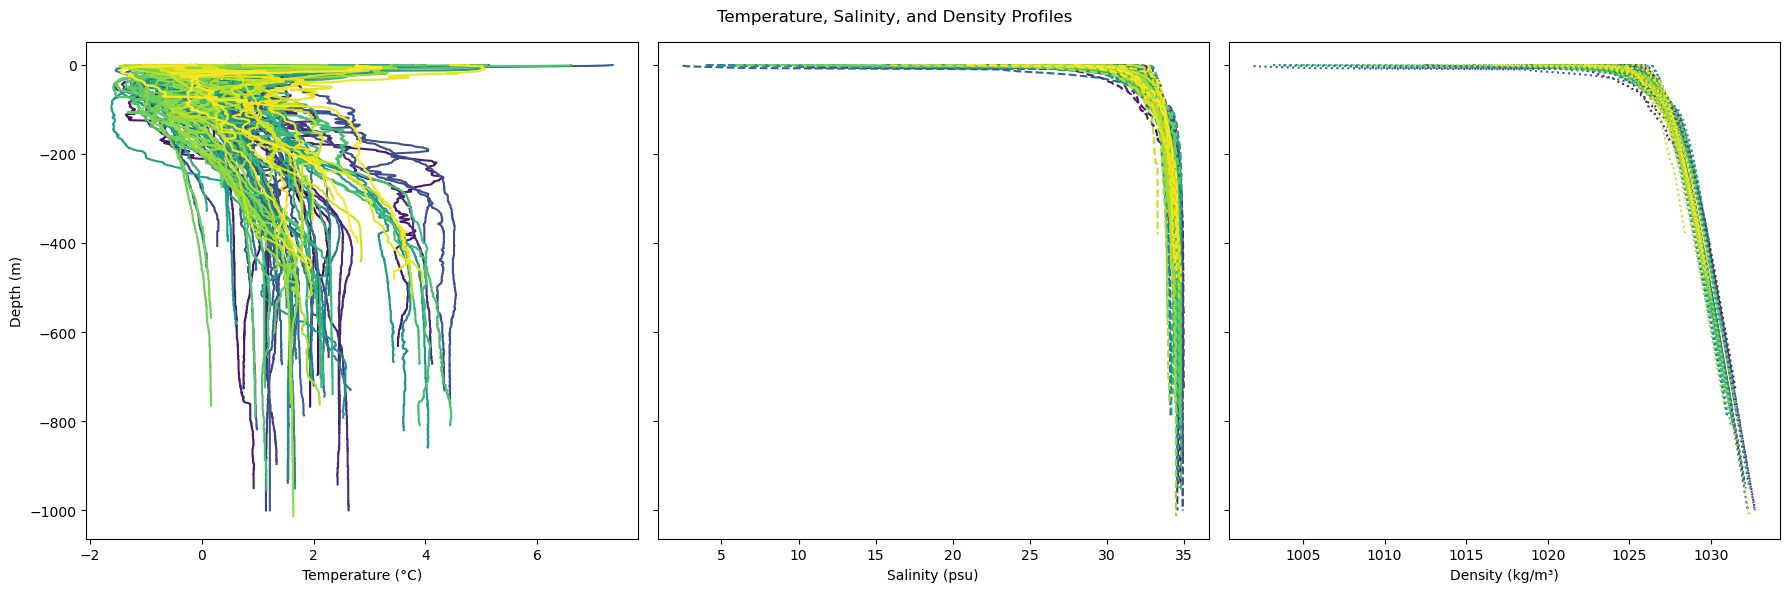

Saved to ..\..\data\ctd_plume_simulations\omg_ctd_profiles.nc
Dropped profiles saved to ..\..\data\ctd_plume_simulations\omg_ctd_profiles_dropped.nc


NoneType: None


Dask cluster closed.


In [4]:
cluster = LocalCluster()
client = Client(cluster)
print(f"Dask dashboard: {client.dashboard_link}")

try:
    combined_omg_ctd_ds, dropped_omg_ctd_ds = process_ctd_profiles(
        axctd_date_filter_csv=axctd_date_filter_csv,
        combined_ctd_dir=combined_ctd_dir,
        smoothing_window=1
    )

    if combined_omg_ctd_ds is not None:
        fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
        colors = plt.cm.viridis(np.linspace(0, 1, len(combined_omg_ctd_ds.profile)))

        for idx, profile_id in enumerate(combined_omg_ctd_ds.profile.values):
            ds_profile = combined_omg_ctd_ds.sel(profile=profile_id)
            axs[0].plot(ds_profile['temperature'], ds_profile['depth_m'] * -1, color=colors[idx])
            axs[1].plot(ds_profile['salinity'],    ds_profile['depth_m'] * -1, color=colors[idx], linestyle='--')
            axs[2].plot(ds_profile['density'],     ds_profile['depth_m'] * -1, color=colors[idx], linestyle=':')

        for ax, xlabel in zip(axs, ['Temperature (°C)', 'Salinity (psu)', 'Density (kg/m³)']):
            ax.set_xlabel(xlabel)
        axs[0].set_ylabel('Depth (m)')
        plt.suptitle('Temperature, Salinity, and Density Profiles')
        plt.tight_layout()
        plt.show()

        combined_omg_ctd_ds.to_netcdf(OUTPUT_NC_PATH)
        print(f"Saved to {OUTPUT_NC_PATH}")

        if dropped_omg_ctd_ds is not None:
            dropped_nc_path = str(OUTPUT_NC_PATH).replace('.nc', '_dropped.nc')
            dropped_omg_ctd_ds.to_netcdf(dropped_nc_path)
            print(f"Dropped profiles saved to {dropped_nc_path}")
    else:
        print("No dataset returned — check that files exist and paths are correct.")


    import traceback
    traceback.print_exc()

finally:
    client.close()
    cluster.close()
    print("Dask cluster closed.")

In [5]:
combined_omg_ctd_ds = xr.open_dataset(OUTPUT_NC_PATH)

start_year = combined_omg_ctd_ds['date'].min(skipna=True)
end_year = combined_omg_ctd_ds['date'].max(skipna=True)
print(f"Date range: {start_year.values} — {end_year.values}")
print(combined_omg_ctd_ds)

Date range: 2016-09-14T10:51:23.040000000 — 2021-09-16T12:18:13.000000000
<xarray.Dataset> Size: 3MB
Dimensions:      (profile: 99, depth_m: 1014)
Coordinates:
  * profile      (profile) int64 792B 1 2 3 4 5 6 7 ... 114 115 116 117 118 119
  * depth_m      (depth_m) float64 8kB 0.0 1.0 2.0 ... 1.012e+03 1.013e+03
    date         (profile) datetime64[ns] 792B 2016-09-24T18:30:48 ... 2018-0...
    latitude     (profile) float64 792B ...
    longitude    (profile) float64 792B ...
Data variables:
    temperature  (profile, depth_m) float64 803kB ...
    salinity     (profile, depth_m) float64 803kB ...
    depth        (profile, depth_m) float64 803kB ...
    density      (profile, depth_m) float64 803kB ...


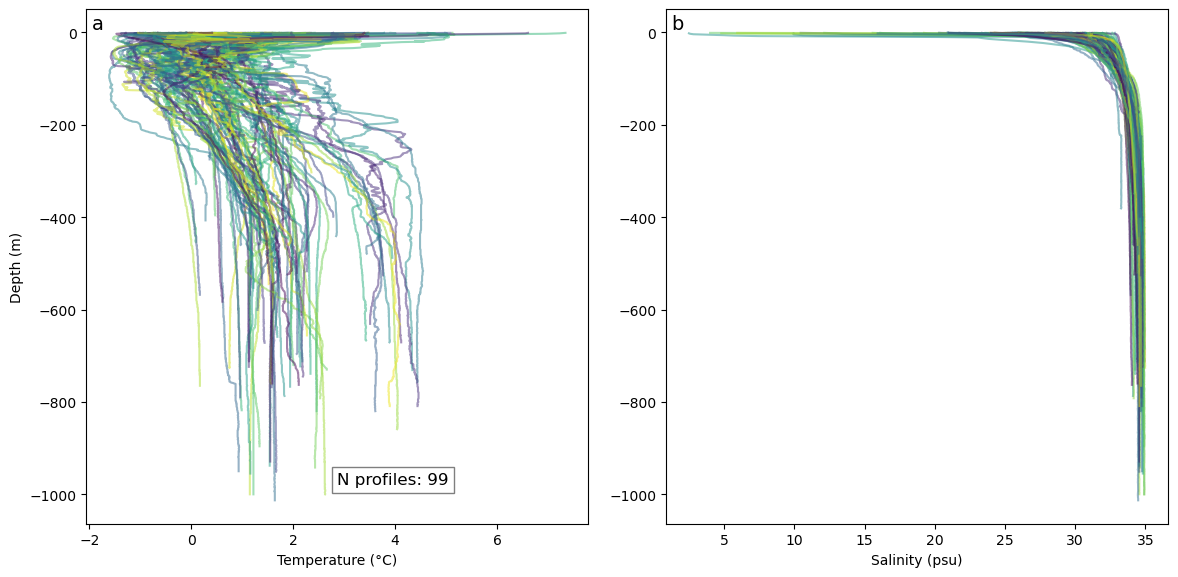

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plt.rcParams.update({'font.size': 14})
colormap = plt.get_cmap('viridis', len(combined_omg_ctd_ds.profile))
colors = np.random.permutation([colormap(i) for i in range(len(combined_omg_ctd_ds.profile))])

for idx, profile in enumerate(combined_omg_ctd_ds.profile):
    axs[0].plot(
        combined_omg_ctd_ds['temperature'].sel(profile=profile),
        combined_omg_ctd_ds['depth'].sel(profile=profile) * -1,
        color=colors[idx], alpha=0.5)
    axs[1].plot(
        combined_omg_ctd_ds['salinity'].sel(profile=profile),
        combined_omg_ctd_ds['depth'].sel(profile=profile) * -1,
        color=colors[idx], alpha=0.5)

axs[0].set_xlabel('Temperature (°C)')
axs[0].set_ylabel('Depth (m)')
axs[1].set_xlabel('Salinity (psu)')

axs[0].text(0.5, 0.1, f'N profiles: {len(combined_omg_ctd_ds.profile)}', transform=axs[0].transAxes,
            fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axs[0].text(0.01, 0.99, 'a', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
axs[1].text(0.01, 0.99, 'b', transform=axs[1].transAxes, fontsize=14, verticalalignment='top')
plt.tight_layout()
plt.show()

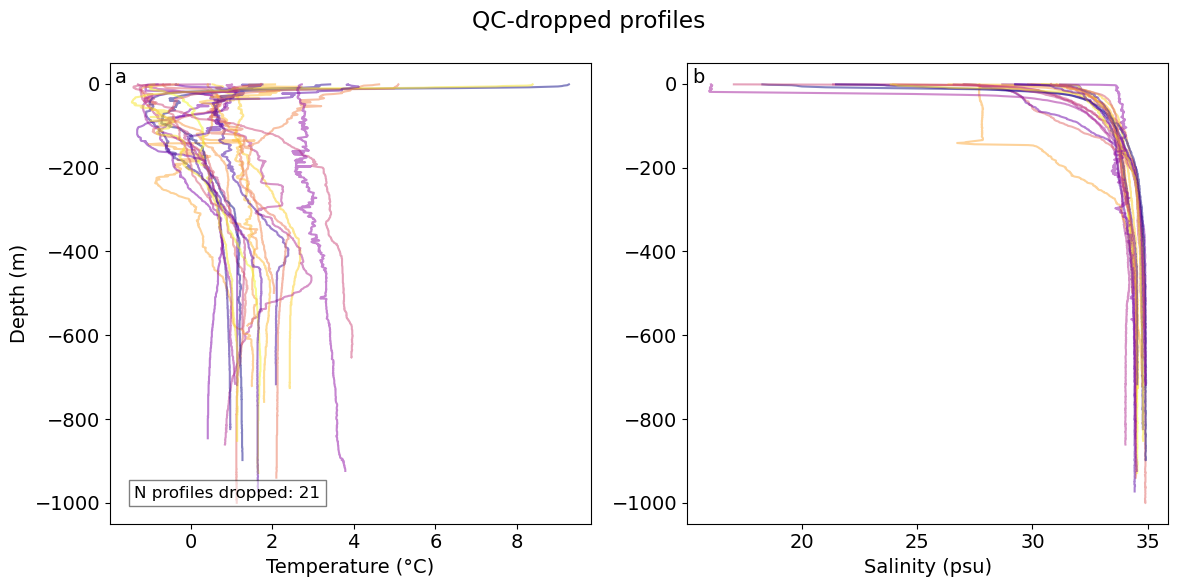

In [7]:
dropped_nc_path = str(OUTPUT_NC_PATH).replace('.nc', '_dropped.nc')
dropped_omg_ctd_ds = xr.open_dataset(dropped_nc_path)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plt.rcParams.update({'font.size': 14})
colormap = plt.get_cmap('plasma', len(dropped_omg_ctd_ds.profile))
colors = np.random.permutation([colormap(i) for i in range(len(dropped_omg_ctd_ds.profile))])

for idx, profile in enumerate(dropped_omg_ctd_ds.profile):
    axs[0].plot(
        dropped_omg_ctd_ds['temperature'].sel(profile=profile),
        dropped_omg_ctd_ds['depth'].sel(profile=profile) * -1,
        color=colors[idx], alpha=0.5)
    axs[1].plot(
        dropped_omg_ctd_ds['salinity'].sel(profile=profile),
        dropped_omg_ctd_ds['depth'].sel(profile=profile) * -1,
        color=colors[idx], alpha=0.5)

axs[0].set_xlabel('Temperature (°C)')
axs[0].set_ylabel('Depth (m)')
axs[1].set_xlabel('Salinity (psu)')

axs[0].text(0.05, 0.05, f'N profiles dropped: {len(dropped_omg_ctd_ds.profile)}',
            transform=axs[0].transAxes, fontsize=12, verticalalignment='bottom',
            bbox=dict(facecolor='white', alpha=0.5))
axs[0].text(0.01, 0.99, 'a', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
axs[1].text(0.01, 0.99, 'b', transform=axs[1].transAxes, fontsize=14, verticalalignment='top')
plt.suptitle('QC-dropped profiles')
plt.tight_layout()
plt.show()

In [8]:
# %matplotlib widget

# # Switch to combined_omg_ctd_ds to inspect kept profiles instead
# _ds = combined_omg_ctd_ds

# colormap = plt.get_cmap('plasma', len(_ds.profile))
# colors = list(np.random.permutation([colormap(i) for i in range(len(_ds.profile))]))

# fig, axs = plt.subplots(1, 2, figsize=(14, 7))
# plt.rcParams.update({'font.size': 13})

# line_map = {}  # artist → profile id

# for idx, profile in enumerate(_ds.profile):
#     pid = int(profile.values)
#     c = colors[idx]
#     l0, = axs[0].plot(_ds['temperature'].sel(profile=profile),
#                       _ds['depth'].sel(profile=profile) * -1,
#                       color=c, alpha=0.4, lw=1, picker=5)
#     l1, = axs[1].plot(_ds['salinity'].sel(profile=profile),
#                       _ds['depth'].sel(profile=profile) * -1,
#                       color=c, alpha=0.4, lw=1, picker=5)
#     line_map[l0] = pid
#     line_map[l1] = pid

# axs[0].set_xlabel('Temperature (°C)')
# axs[0].set_ylabel('Depth (m)')
# axs[1].set_xlabel('Salinity (psu)')

# info_box = fig.text(0.5, 0.01, 'Click a profile to identify it',
#                     ha='center', fontsize=11,
#                     bbox=dict(facecolor='lightyellow', alpha=0.9, boxstyle='round'))
# plt.suptitle('QC-dropped profiles — click to identify')
# plt.tight_layout(rect=[0, 0.06, 1, 1])


# def on_pick(event):
#     artist = event.artist
#     if artist not in line_map:
#         return
#     pid = line_map[artist]
#     prof = _ds.sel(profile=pid)
#     date = str(prof['date'].values)[:19]
#     lat  = float(prof['latitude'].values)
#     lon  = float(prof['longitude'].values)

#     for l in line_map:
#         l.set_alpha(0.1)
#         l.set_linewidth(1)
#     for l, p in line_map.items():
#         if p == pid:
#             l.set_alpha(1.0)
#             l.set_linewidth(2.5)

#     msg = f"Profile ID: {pid}  |  Date: {date}  |  Lat: {lat:.3f}°  Lon: {lon:.3f}°"
#     info_box.set_text(msg)
#     print(msg)
#     fig.canvas.draw_idle()


# fig.canvas.mpl_connect('pick_event', on_pick)
# plt.show()

## Run Plume Model Ensemble

Latin Hypercube Sampling (LHS) generates 40 parameter combinations per CTD profile:
- **Q₀**: subglacial discharge rate (0.005–5 m³/s)
- **α**: entrainment coefficient (0.05–0.15; Slater et al. 2022)
- **z_max**: maximum plume depth factor (0.6–1.4 × fjord depth)

Runs in parallel via Dask. Results saved to `plume_output_path`.

In [9]:
import math
from dask.distributed import as_completed as dask_as_completed

sys.path.append(os.path.join(os.getcwd(), 'plume_modelling'))
from run_PLUME import run_plume

def create_xarray_dataset(results):
    max_depth = max(len(r['depth_profile']) for r in results if r is not None)

    temperature_profiles = np.full((len(results), max_depth), np.nan)
    depth_profiles = np.full((len(results), max_depth), np.nan)
    ctd_temp_profiles = np.full((len(results), max_depth), np.nan)
    ctd_density_profiles = np.full((len(results), max_depth), np.nan)
    ctd_salinity_profiles = np.full((len(results), max_depth), np.nan)

    Q0_values, alpha_values, z_max_values = [], [], []
    lat_values, lon_values, profile_id_values = [], [], []

    for idx, r in enumerate(results):
        if r is not None:
            profile_len = len(r['depth_profile'])
            temperature_profiles[idx, :profile_len] = r['temperature_profile']
            depth_profiles[idx, :profile_len] = r['depth_profile']
            ctd_temp_profiles[idx, :profile_len] = r['ctd_temp_profile']
            ctd_density_profiles[idx, :profile_len] = r['ctd_density_profile']
            ctd_salinity_profiles[idx, :profile_len] = r['ctd_salinity_profile']
            Q0_values.append(r['model_params']['Q0'])
            alpha_values.append(r['model_params']['alpha'])
            z_max_values.append(r['model_params']['z_max'])
            lat_values.append(r['latitude'])
            lon_values.append(r['longitude'])
            profile_id_values.append(r['profile_id'])

    return xr.Dataset({
        'temperature_profile': xr.DataArray(temperature_profiles, dims=["profile", "depth"]),
        'depth_profile': xr.DataArray(depth_profiles, dims=["profile", "depth"]),
        'ctd_temp_profile': xr.DataArray(ctd_temp_profiles, dims=["profile", "depth"]),
        'ctd_density_profile': xr.DataArray(ctd_density_profiles, dims=["profile", "depth"]),
        'ctd_salinity_profile': xr.DataArray(ctd_salinity_profiles, dims=["profile", "depth"]),
        'Q0': xr.DataArray(Q0_values, dims=["profile"]),
        'alpha': xr.DataArray(alpha_values, dims=["profile"]),
        'z_max': xr.DataArray(z_max_values, dims=["profile"]),
    }, coords={
        'latitude': ('profile', lat_values),
        'longitude': ('profile', lon_values),
        'ctd_profile_id': ('profile', profile_id_values),
    })


def run_plume_profile(profile_idx, depth, temperature, salinity, density, Q0, alpha, z_max, Na, lat=None, lon=None):
    depth_sub = depth[depth >= z_max]
    if len(depth_sub) == 0:
        return None
    temperature_sub = temperature[:len(depth_sub)]
    salinity_sub = salinity[:len(depth_sub)]

    try:
        solution = run_plume(
            depth_sub, np.full(depth_sub.shape, 0), temperature_sub, salinity_sub,
            np.full(depth_sub.shape, Na), Q0, alpha, stop_on_zero_velocity=True
        )
    except Exception:
        return None

    if solution is None:
        return None

    return {
        'profile_id': profile_idx,
        'Q0': Q0, 'alpha': alpha, 'z_max': z_max,
        'temperature_profile': solution['T'],
        'depth_profile': solution['z'],
        'ctd_temp_profile': solution['Ta'],
        'ctd_density_profile': solution['rhoa'],
        'ctd_salinity_profile': solution['Sa'],
        'model_params': {'Q0': Q0, 'alpha': alpha, 'z_max': z_max},
        'latitude': lat, 'longitude': lon,
    }


def run_plume_with_ctd_profiles(ctd_data, num_samples=30):
    Na = 1
    Q0_range, alpha_range, z_max_range = (0.005, 5), (0.05, 0.15), (0.6, 1.4)  # alpha range: Slater et al. 2022; Kimura et al. 2014

    lhs_samples = lhs(3, samples=num_samples)
    sample_params = np.column_stack([
        lhs_samples[:, 0] * (Q0_range[1] - Q0_range[0]) + Q0_range[0],
        lhs_samples[:, 1] * (alpha_range[1] - alpha_range[0]) + alpha_range[0],
        lhs_samples[:, 2] * (z_max_range[1] - z_max_range[0]) + z_max_range[0],
    ])

    cluster = LocalCluster()
    client = Client(cluster)
    print(f"Dask dashboard: {client.dashboard_link}")

    tasks = []
    for profile_idx in range(ctd_data.sizes['profile']):
        depth = ctd_data['depth'].isel(profile=profile_idx).values * -1
        temperature = ctd_data['temperature'].isel(profile=profile_idx).values
        salinity = ctd_data['salinity'].isel(profile=profile_idx).values
        density = ctd_data['density'].isel(profile=profile_idx).values
        lat = ctd_data['latitude'].isel(profile=profile_idx).values
        lon = ctd_data['longitude'].isel(profile=profile_idx).values

        valid_idx = ~np.isnan(depth) & ~np.isnan(temperature) & ~np.isnan(salinity) & ~np.isnan(density)
        depth, temperature, salinity, density = depth[valid_idx], temperature[valid_idx], salinity[valid_idx], density[valid_idx]

        valid_idx = (temperature != 0.0) & (salinity != 0.0)
        depth, temperature, salinity, density = depth[valid_idx], temperature[valid_idx], salinity[valid_idx], density[valid_idx]

        for Q0, alpha, z_max_param in sample_params:
            depth_copy = depth.copy()
            temperature_copy = temperature.copy()
            salinity_copy = salinity.copy()
            density_copy = density.copy()

            if depth_copy.size == 0:
                continue

            max_depth = depth_copy.min()
            depth_spacing = np.diff(depth_copy).mean()
            z_max = np.round(max_depth * z_max_param)

            if z_max_param > 1.0:
                additional_depths = np.arange(max_depth + depth_spacing, z_max + depth_spacing, depth_spacing)
                depth_copy = np.append(depth_copy, additional_depths)
                temperature_copy = np.concatenate([temperature_copy, np.full(len(additional_depths), temperature_copy[-1])])
                salinity_copy = np.concatenate([salinity_copy, np.full(len(additional_depths), salinity_copy[-1])])
                density_copy = np.concatenate([density_copy, np.full(len(additional_depths), density_copy[-1])])
            elif z_max_param < 1.0:
                depth_index = np.where(depth_copy <= z_max)[0][-1] + 1
                depth_copy = depth_copy[:depth_index]
                temperature_copy = temperature_copy[:depth_index]
                salinity_copy = salinity_copy[:depth_index]
                density_copy = density_copy[:depth_index]

            # Reconcile minor length mismatches (<=1 element)
            if len(depth_copy) != len(temperature_copy) or len(depth_copy) != len(salinity_copy) or len(depth_copy) != len(density_copy):
                if abs(len(depth_copy) - len(temperature_copy)) < 2:
                    for arr_name, arr in [('temperature_copy', temperature_copy), ('salinity_copy', salinity_copy), ('density_copy', density_copy)]:
                        pass
                    temperature_copy = temperature_copy[:len(depth_copy)] if len(temperature_copy) > len(depth_copy) else np.concatenate([temperature_copy, np.full(len(depth_copy) - len(temperature_copy), temperature_copy[-1])])
                    salinity_copy = salinity_copy[:len(depth_copy)] if len(salinity_copy) > len(depth_copy) else np.concatenate([salinity_copy, np.full(len(depth_copy) - len(salinity_copy), salinity_copy[-1])])
                    density_copy = density_copy[:len(depth_copy)] if len(density_copy) > len(depth_copy) else np.concatenate([density_copy, np.full(len(depth_copy) - len(density_copy), density_copy[-1])])
                else:
                    continue

            valid_idx = ~np.isnan(depth_copy) & ~np.isnan(temperature_copy) & ~np.isnan(salinity_copy) & ~np.isnan(density_copy)
            depth_copy, temperature_copy, salinity_copy, density_copy = depth_copy[valid_idx], temperature_copy[valid_idx], salinity_copy[valid_idx], density_copy[valid_idx]

            if depth_copy.size < 10:
                continue

            tasks.append(client.submit(run_plume_profile, profile_idx, depth_copy, temperature_copy, salinity_copy, density_copy, Q0, alpha, z_max, Na, lat, lon))

    results = []
    with tqdm(total=len(tasks), desc="Running plume ensemble (Dask)") as pbar:
        for future, result in dask_as_completed(tasks, with_results=True):
            if result is not None:
                results.append(result)
            pbar.update(1)

    client.close()
    cluster.close()
    return results


results = run_plume_with_ctd_profiles(combined_omg_ctd_ds, num_samples=40)
results_ds = create_xarray_dataset(results)
results_ds.to_netcdf(plume_output_path)

Dask dashboard: http://127.0.0.1:8787/status


Running plume ensemble (Dask):   0%|          | 0/3960 [00:00<?, ?it/s]